<!-- Trabalho Desenvolvido no Curso da Data Science Academy - www.datascienceacademy.com.br -->
# <font color='blue'>Data Science Academy</font>
# <font color='blue'>Fundamentos de Linguagem Python - Do Básico a Aplicações de IA</font>
# <font color='blue'>Mini-Projeto 1</font>
# <font color='blue'>Análise de Vendas Para Loja de E-commerce com NumPy, Pandas e Matplotlib</font>

## 1. Definição do Problema de Negócio

**1.1. O Problema de Negócio**

Nossa loja de e-commerce está em fase de crescimento, registrando um volume cada vez maior de transações diárias. No entanto, essa grande quantidade de dados de vendas, em seu estado bruto, é como um baú de tesouro trancado: sabemos que há valor ali, mas não conseguimos acessá-lo.

Atualmente, muitas de nossas decisões estratégicas são baseadas em intuição e observações parciais, o que nos leva a enfrentar os seguintes desafios:

- Gestão de Estoque Ineficiente: Não temos clareza sobre quais produtos são nossos "campeões de venda" e quais estão parados nas prateleiras. Isso resulta em excesso de estoque de itens de baixa procura e falta de produtos de alta demanda.

- Marketing com Baixo Retorno: Nossas campanhas de marketing são genéricas, pois não sabemos quais categorias de produtos atraem mais os clientes ou em quais regiões geográficas nosso público está mais concentrado.

- Perda de Oportunidades Sazonais: Não conseguimos identificar padrões ou tendências de vendas ao longo dos meses. Isso nos impede de planejar promoções estratégicas para períodos de alta ou de criar ações para impulsionar as vendas em meses de baixa.

- Expansão sem Direção: Temos o desejo de expandir, mas não sabemos quais mercados regionais são mais promissores ou onde nossos esforços logísticos deveriam ser focados.

O problema central é a falta de visibilidade clara sobre a performance do negócio, o que nos impede de tomar decisões rápidas, inteligentes e baseadas em evidências.

**1.2. Objetivos do Projeto**

Este projeto de análise de dados visa transformar nossos dados brutos de vendas em insights acionáveis. O objetivo é responder a quatro perguntas de negócio fundamentais:

- O que vender? Identificar os produtos de maior sucesso para otimizar nosso portfólio e estoque.
<!-- Trabalho Desenvolvido no Curso da Data Science Academy - www.datascienceacademy.com.br -->
- Onde focar? Compreender quais categorias de produtos geram a maior parte da nossa receita.

- Quando agir? Analisar a performance de vendas ao longo do tempo para identificar tendências, picos e sazonalidades.

- Para onde expandir? Mapear a distribuição geográfica de nossas vendas para descobrir nossos mercados mais fortes.

**1.3. Solução Proposta**

A solução consiste em consolidar, limpar e analisar o histórico de dados de vendas da nossa plataforma. Utilizando ferramentas de análise de dados (como Python com Pandas, NumPy e Matplotlib), vamos processar essas informações e criar um relatório visual que apresente as descobertas de forma clara e intuitiva para as equipes de gestão, marketing e operações.

**1.4. Resultados Esperados e Benefícios de Negócio**

Ao final deste projeto, esperamos alcançar os seguintes resultados:

- Otimização de Estoque: Com a lista dos produtos mais e menos vendidos, poderemos ajustar nossas compras, reduzir custos com armazenamento e evitar a perda de vendas por falta de produto.

- Marketing Direcionado e Eficaz: Sabendo quais categorias e regiões são mais lucrativas, a equipe de marketing poderá criar campanhas segmentadas, aumentando o retorno sobre o investimento (ROI).

- Planejamento Estratégico: A visualização das tendências mensais permitirá um melhor planejamento financeiro, promocional e de recursos, antecipando períodos de alta e baixa demanda.

- Decisões Baseadas em Dados: Substituiremos a intuição por dados concretos, criando uma cultura orientada a dados que impulsionará o crescimento sustentável do negócio.

## 2. Importação das Bibliotecas

In [27]:
# Instala o pacote watermark
#!pip install -q -U watermark

In [28]:
# Importação da biblioteca para manipulação de dados em tabelas
import pandas as pd

# Importação da biblioteca NumPy para operações matemáticas e arrays
import numpy as np

# Importação da biblioteca Matplotlib para geração de gráficos
import matplotlib.pyplot as plt

# Importação da biblioteca Seaborn para visualização estatística de dados
import seaborn as sns

# Importação da biblioteca random para geração de números aleatórios
import random

# Importação das classes datetime e timedelta para manipulação de datas e intervalos de tempo
from datetime import datetime, timedelta

from fontTools.misc.cython import returns
from matplotlib.lines import lineStyles

# Comando mágico do Jupyter Notebook que permite exibir gráficos diretamente no notebook
%matplotlib inline

In [29]:
%reload_ext watermark
%watermark -a "Data Science Academy"

Author: Data Science Academy



In [10]:
%watermaak --iversions

UsageError: Line magic function `%watermaak` not found.


In [30]:
# Para instalar uma versão específica de um pacote, podemos fazer assim (por exemplo):
# !pip install -q pandas==2.3.1

## 3. Função Para Geração de Dados Fictícios

Excelente forma de praticar muito do que vimos até aqui neste capítulo.

In [31]:
def gera_dados_ficticios(num_registros = 600):

    """
    Gera um DataFrame do Pandas com dados de vendas fictícios
    """

    print(f"\nIniciando a geração de {num_registros} registrando vendas...")

    produtos = {
        'Laptop Gamer' : {'categoria' : 'Eletrônicos', 'preco' : 7500.00},
        'Mouse Vertical' : {'categoria' : 'Acessórios', 'preco' : 250.00},
        'Teclado Mecânico' : {'categoria' : 'Acessórios', 'preco' : 550.00},
        'Monitor Ultrawide' : {'categoria' : 'Eletrônicos', 'preco' : 2800.00},
        'Cadeira Gamer' : {'categoria' : 'Móveis', 'preco' : 1200.00},
        'Headset 7.1' : {'categoria' : 'Acessórios', 'preco' : 800.00},
        'Placa de Vídeo' : {'categoria' : 'Hardware', 'preco' : 4500.00},
        'SSD 1TB' : {'categoria' : 'Hardware', 'preco' : 600.00}
    }

    lista_produtos = list(produtos.keys())

    cidades_estados = {
        'São Paulo' : 'SP', 'Rio de Janeiro' : 'RJ', 'Belo Horizonte' : 'MG',
        'Porto Alegre' : 'RS', 'Salvador' : 'BA', 'Curitiba' : 'PR', 'Fortaleza' : 'CE'
    }

    lista_cidade = list(cidades_estados.keys())

    dados_vendas = []

    data_inicial = datetime(2026, 1, 1)

    for i in range(num_registros):

        produto_nome = random.choice(lista_produtos)
        cidade = random.choice(lista_cidade)
        quantidade = np.random.randint(1, 8)
        data_pedido = data_inicial + timedelta(days = int(i / 5), hours = random.randint(0, 23))

        if produto_nome in ['Mouse Vertical', 'Teclado Mecânico']:
            preco_unitario = produtos[produto_nome]['preco'] * np.random.uniform(0.9, 1.0)

        else:
            preco_unitario = produtos[produto_nome]['preco']

        dados_vendas.append({
            'ID_Pedido' : 1000 + i,
            'Data_Pedido' : data_pedido,
            'Nome_Produto' : produto_nome,
            'Categoria' : produtos[produto_nome]['categoria'],
            'Preco_Unitario' : round(preco_unitario, 2),
            'Quantidade' : quantidade,
            'ID_Cliente' : np.random.randint(100, 150),
            'Cidade' : cidade,
            'Estado' : cidades_estados[cidade]
        })

    print("Geração de dados concuída.\n")

    return pd.DataFrame(dados_vendas)

## 4. Gerar, Carregar e Explorar os Dados

In [32]:
# Gera os dados chamando a função da célula anterior
df_vendas = gera_dados_ficticios(500)


Iniciando a geração de 500 registrando vendas...
Geração de dados concuída.



In [33]:
type(df_vendas)

pandas.DataFrame

In [34]:
# Shape
df_vendas.shape

(500, 9)

In [35]:
# Exibe as 5 primeiras linhas do DataFrame
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
0,1000,2026-01-01 12:00:00,Headset 7.1,Acessórios,800.0,6,102,São Paulo,SP
1,1001,2026-01-01 23:00:00,Cadeira Gamer,Móveis,1200.0,2,108,Belo Horizonte,MG
2,1002,2026-01-01 19:00:00,Monitor Ultrawide,Eletrônicos,2800.0,2,148,Belo Horizonte,MG
3,1003,2026-01-01 17:00:00,Monitor Ultrawide,Eletrônicos,2800.0,4,133,Curitiba,PR
4,1004,2026-01-01 23:00:00,Laptop Gamer,Eletrônicos,7500.0,2,102,São Paulo,SP


In [36]:
# Exibe as 5 últimas linhas do DataFrame
df_vendas.tail()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
495,1495,2026-04-10 17:00:00,Cadeira Gamer,Móveis,1200.00,5,133,Salvador,BA
496,1496,2026-04-10 16:00:00,Headset 7.1,Acessórios,800.00,1,114,Rio de Janeiro,RJ
497,1497,2026-04-10 22:00:00,Placa de Vídeo,Hardware,4500.00,2,111,Salvador,BA
498,1498,2026-04-10 23:00:00,Teclado Mecânico,Acessórios,549.18,5,139,Porto Alegre,RS
499,1499,2026-04-10 20:00:00,Teclado Mecânico,Acessórios,527.01,7,104,Fortaleza,CE


In [37]:
# Exibe informações gerais sobre o DataFrame (tipos de dados, valores não nulos)
df_vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       500 non-null    int64         
 1   Data_Pedido     500 non-null    datetime64[us]
 2   Nome_Produto    500 non-null    str           
 3   Categoria       500 non-null    str           
 4   Preco_Unitario  500 non-null    float64       
 5   Quantidade      500 non-null    int64         
 6   ID_Cliente      500 non-null    int64         
 7   Cidade          500 non-null    str           
 8   Estado          500 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(3), str(4)
memory usage: 52.6 KB


In [38]:
# Resumo estatístico
df_vendas.describe()

,ID_Pedido,Data_Pedido,Preco_Unitario,Quantidade,ID_Cliente
count,500.000000,500,500.000000,500.000000,500.000000
mean,1249.500000,2026-02-19 23:53:02.400000,2286.552200,3.996000,124.864000
min,1000.000000,2026-01-01 12:00:00,225.860000,1.000000,100.000000
25%,1124.750000,2026-01-26 02:00:00,600.000000,2.000000,112.000000
50%,1249.500000,2026-02-19 22:00:00,1200.000000,4.000000,125.000000
75%,1374.250000,2026-03-16 21:15:00,4500.000000,6.000000,138.000000
max,1499.000000,2026-04-10 23:00:00,7500.000000,7.000000,149.000000
std,144.481833,NaN,2383.994886,1.984909,14.805266


In [39]:
# Tipos de dados
df_vendas.dtypes

ID_Pedido                  int64
Data_Pedido       datetime64[us]
Nome_Produto                 str
Categoria                    str
Preco_Unitario           float64
Quantidade                 int64
ID_Cliente                 int64
Cidade                       str
Estado                       str
dtype: object

## 5. Limpeza, Pré-Processamento e Engenharia de Atributos

In [40]:
# Se a coluna 'Data_Pedido' não estiver como tipo datetime, precisamos fazer a conversão explícita
# A coluna pode ser usada para análise temporal
df_vendas['Data_Pedido'] = pd.to_datetime(df_vendas['Data_Pedido'])

In [41]:
# Engenharia de atributos
# Criando a coluna 'Faturamento' (preço x quantidade)
df_vendas['Faturamento'] = df_vendas['Preco_Unitario'] * df_vendas['Quantidade']

In [42]:
# Engenharia de atributos
# Usando uma função lambda para criar uma coluna de status de entrega
df_vendas['Status_Entrega'] = df_vendas['Estado'].apply(lambda estado : 'Rápida' if estado in ['SP', 'RJ', 'MG'] else 'Normal')

In [43]:
# Exibe informações gerais sobre o DataFrame (tipos de dados, valores não nulos
df_vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       500 non-null    int64         
 1   Data_Pedido     500 non-null    datetime64[us]
 2   Nome_Produto    500 non-null    str           
 3   Categoria       500 non-null    str           
 4   Preco_Unitario  500 non-null    float64       
 5   Quantidade      500 non-null    int64         
 6   ID_Cliente      500 non-null    int64         
 7   Cidade          500 non-null    str           
 8   Estado          500 non-null    str           
 9   Faturamento     500 non-null    float64       
 10  Status_Entrega  500 non-null    str           
dtypes: datetime64[us](1), float64(2), int64(3), str(5)
memory usage: 63.6 KB


In [44]:
# Exibe as 5 primeiras linhas novamente para ver as novas colunas
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega
0,1000,2026-01-01 12:00:00,Headset 7.1,Acessórios,800.0,6,102,São Paulo,SP,4800.0,Rápida
1,1001,2026-01-01 23:00:00,Cadeira Gamer,Móveis,1200.0,2,108,Belo Horizonte,MG,2400.0,Rápida
2,1002,2026-01-01 19:00:00,Monitor Ultrawide,Eletrônicos,2800.0,2,148,Belo Horizonte,MG,5600.0,Rápida
3,1003,2026-01-01 17:00:00,Monitor Ultrawide,Eletrônicos,2800.0,4,133,Curitiba,PR,11200.0,Normal
4,1004,2026-01-01 23:00:00,Laptop Gamer,Eletrônicos,7500.0,2,102,São Paulo,SP,15000.0,Rápida


## 6. Análise 1 - Top 10 Produtos Mais Vendidos
<!-- Trabalho Desenvolvido no Curso da Data Science Academy - www.datascienceacademy.com.br -->
Quais os top 10 produtos mais vendidos?

In [45]:
# Agrupa por nome do produto, soma a quantidade e ordena para encontrar os mais vendidos
top_10_produtos = df_vendas.groupby('Nome_Produto')['Quantidade'].sum().sort_values(ascending = False).head(10)

In [46]:
# Exibe o resultado
top_10_produtos

Nome_Produto
SSD 1TB              309
Laptop Gamer         278
Placa de Vídeo       259
Monitor Ultrawide    253
Cadeira Gamer        251
Mouse Vertical       228
Headset 7.1          222
Teclado Mecânico     198
Name: Quantidade, dtype: int64

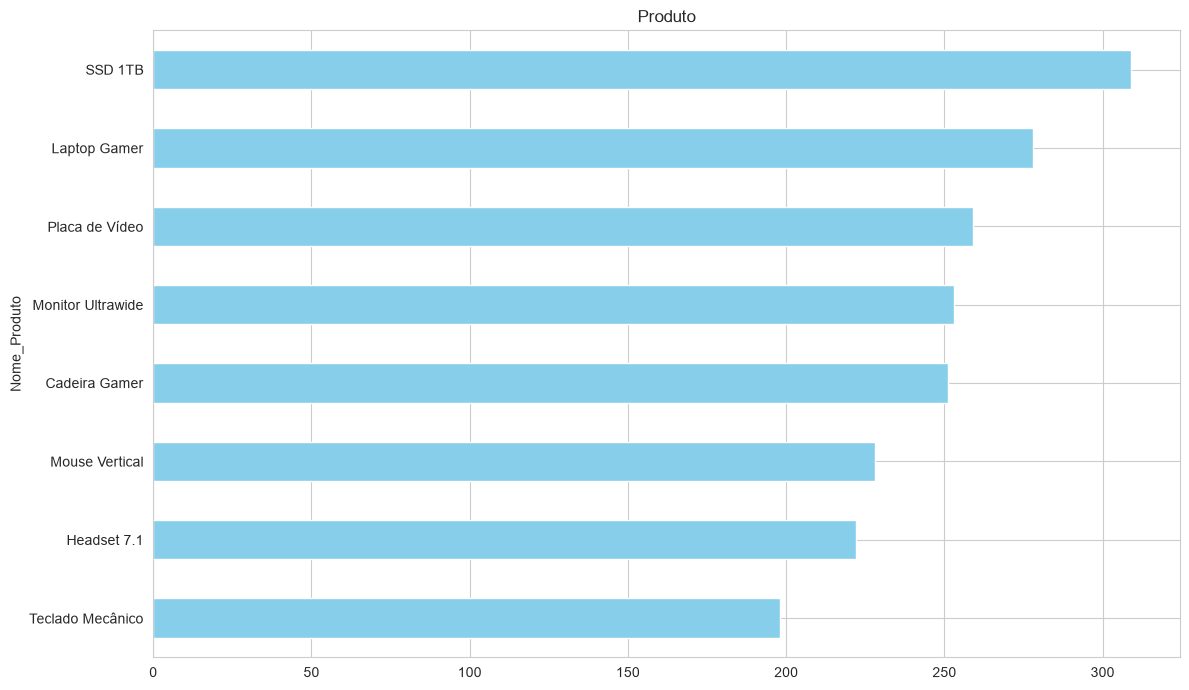

In [48]:
# Define um estilo para os gráficos
sns.set_style("whitegrid")

plt.figure(figsize = (12, 7))

top_10_produtos.sort_values(ascending = True).plot(kind = 'barh', color = 'skyblue')

plt.title('Top 10 Produtos Mais Vendidos', fontsize = 16)
plt.title('Quantidade Vendida', fontsize = 12)
plt.title('Produto', fontsize = 12)

plt.tight_layout()
plt.show()

## 7. Análise 2 - Faturamento Mensal

Qual foi o faturamento mensal?

In [49]:
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega
0,1000,2026-01-01 12:00:00,Headset 7.1,Acessórios,800.0,6,102,São Paulo,SP,4800.0,Rápida
1,1001,2026-01-01 23:00:00,Cadeira Gamer,Móveis,1200.0,2,108,Belo Horizonte,MG,2400.0,Rápida
2,1002,2026-01-01 19:00:00,Monitor Ultrawide,Eletrônicos,2800.0,2,148,Belo Horizonte,MG,5600.0,Rápida
3,1003,2026-01-01 17:00:00,Monitor Ultrawide,Eletrônicos,2800.0,4,133,Curitiba,PR,11200.0,Normal
4,1004,2026-01-01 23:00:00,Laptop Gamer,Eletrônicos,7500.0,2,102,São Paulo,SP,15000.0,Rápida


In [50]:
# Cria uma coluna 'Mes' para facilitar o agrupamento mensal
df_vendas['Mes'] = df_vendas['Data_Pedido'].dt.to_period('M')

In [51]:
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega,Mes
0,1000,2026-01-01 12:00:00,Headset 7.1,Acessórios,800.0,6,102,São Paulo,SP,4800.0,Rápida,2026-01
1,1001,2026-01-01 23:00:00,Cadeira Gamer,Móveis,1200.0,2,108,Belo Horizonte,MG,2400.0,Rápida,2026-01
2,1002,2026-01-01 19:00:00,Monitor Ultrawide,Eletrônicos,2800.0,2,148,Belo Horizonte,MG,5600.0,Rápida,2026-01
3,1003,2026-01-01 17:00:00,Monitor Ultrawide,Eletrônicos,2800.0,4,133,Curitiba,PR,11200.0,Normal,2026-01
4,1004,2026-01-01 23:00:00,Laptop Gamer,Eletrônicos,7500.0,2,102,São Paulo,SP,15000.0,Rápida,2026-01


In [52]:
# Agrupa por mês e soma o faturamento
faturamento_mensal = df_vendas.groupby('Mes')['Faturamento'].sum()

In [53]:
# Converte o índice para string para facilitar a plotagem no gráfico
faturamento_mensal.index = faturamento_mensal.index.strftime('%Y-%m')

In [55]:
# Formata para duas casas decimais
faturamento_mensal.map('R${:,.2f'.format)

ValueError: unmatched '{' in format spec

ValueError: keyword grid_wich is not recognized; valid keywords are ['size', 'width', 'color', 'tickdir', 'pad', 'labelsize', 'labelcolor', 'labelfontfamily', 'zorder', 'gridOn', 'tick1On', 'tick2On', 'label1On', 'label2On', 'length', 'direction', 'left', 'bottom', 'right', 'top', 'labelleft', 'labelbottom', 'labelright', 'labeltop', 'labelrotation', 'labelrotation_mode', 'grid_agg_filter', 'grid_alpha', 'grid_animated', 'grid_antialiased', 'grid_clip_box', 'grid_clip_on', 'grid_clip_path', 'grid_color', 'grid_dash_capstyle', 'grid_dash_joinstyle', 'grid_dashes', 'grid_data', 'grid_drawstyle', 'grid_figure', 'grid_fillstyle', 'grid_gapcolor', 'grid_gid', 'grid_in_layout', 'grid_label', 'grid_linestyle', 'grid_linewidth', 'grid_marker', 'grid_markeredgecolor', 'grid_markeredgewidth', 'grid_markerfacecolor', 'grid_markerfacecoloralt', 'grid_markersize', 'grid_markevery', 'grid_mouseover', 'grid_path_effects', 'grid_picker', 'grid_pickradius', 'grid_rasterized', 'grid_sketch_params', 'gri

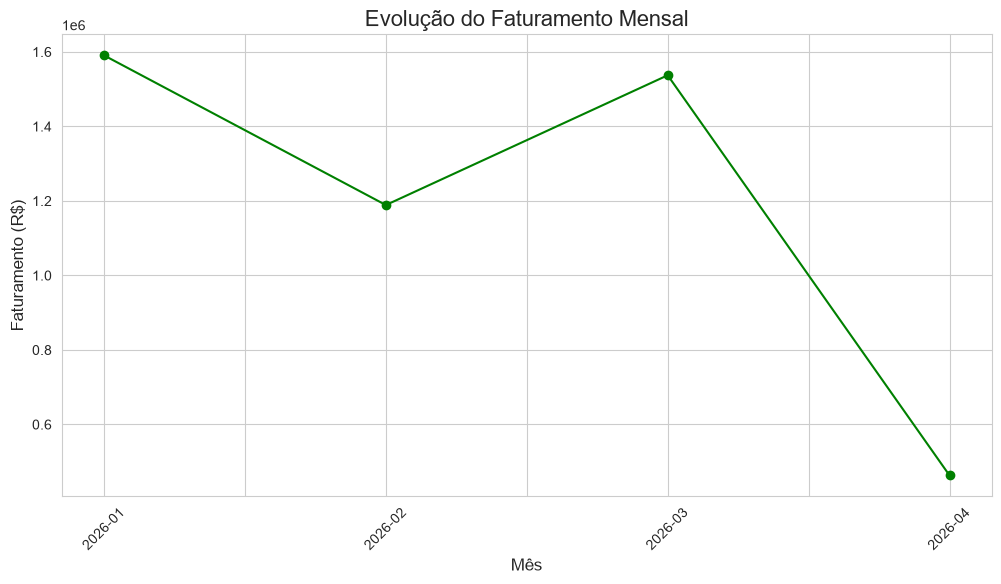

In [56]:
plt.figure(figsize = (12, 6))
faturamento_mensal.plot(kind = 'line', marker = 'o', linestyle = '-', color = 'green')
plt.title('Evolução do Faturamento Mensal', fontsize = 16)
plt.xlabel('Mês', fontsize = 12)
plt.ylabel('Faturamento (R$)', fontsize = 12)
plt.xticks(rotation = 45)
plt.grid(True, wich = 'both', linestyle = '--', linewidth = 0.5)
plt.tight_layout()
plt.show()


## 8. Análise 3 - Vendas Por Estado

Qual o total de vendas por estado?

In [59]:
# Agrupa por estado e soma o faturamento
vendas_estado = df_vendas.groupby('Estado')['Faturamento'].sum().sort_values(ascending = False)

In [60]:
# Formata para duas casas decimais
vendas_estado.map('R$ {:,.2f}'.format)

Estado
RJ    R$ 913,280.83
MG    R$ 740,149.60
SP    R$ 678,215.18
CE    R$ 668,300.39
PR    R$ 665,972.37
BA    R$ 578,135.46
RS    R$ 535,919.26
Name: Faturamento, dtype: str

https://seaborn.pydata.org/generated/seaborn.color_palette.html

In [61]:
plt.figure(figgize = (12, 7))
vendas_estado.plot(kind = 'bar', color = sns.color_palette("husl", 7))
plt.title('Faturamento Por Estado', fontsize = 16)
plt.xlabel('Estado', fontsize = 12)
plt.ylabel('Faturamento (R$)', fontsize = 12)
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

AttributeError: Figure.set() got an unexpected keyword argument 'figgize'

## 9. Análise 4 - Faturamento Por Categoria

Qual o faturamento total por categoria?

In [62]:
# Agrupa por categoria, soma o faturamento e formata como moeda para melhor leitura
faturamneto_categoria = df_vendas.groupby('Categoria')['Faturamento'].sum().sort_values(ascending = False)

In [63]:
faturamneto_categoria.map('R$ {:,.2f}'.format)

Categoria
Eletrônicos    R$ 2,793,400.00
Hardware       R$ 1,350,900.00
Acessórios       R$ 334,473.09
Móveis           R$ 301,200.00
Name: Faturamento, dtype: str

AttributeError: module 'matplotlib.pyplot' has no attribute 'thigt_layout'

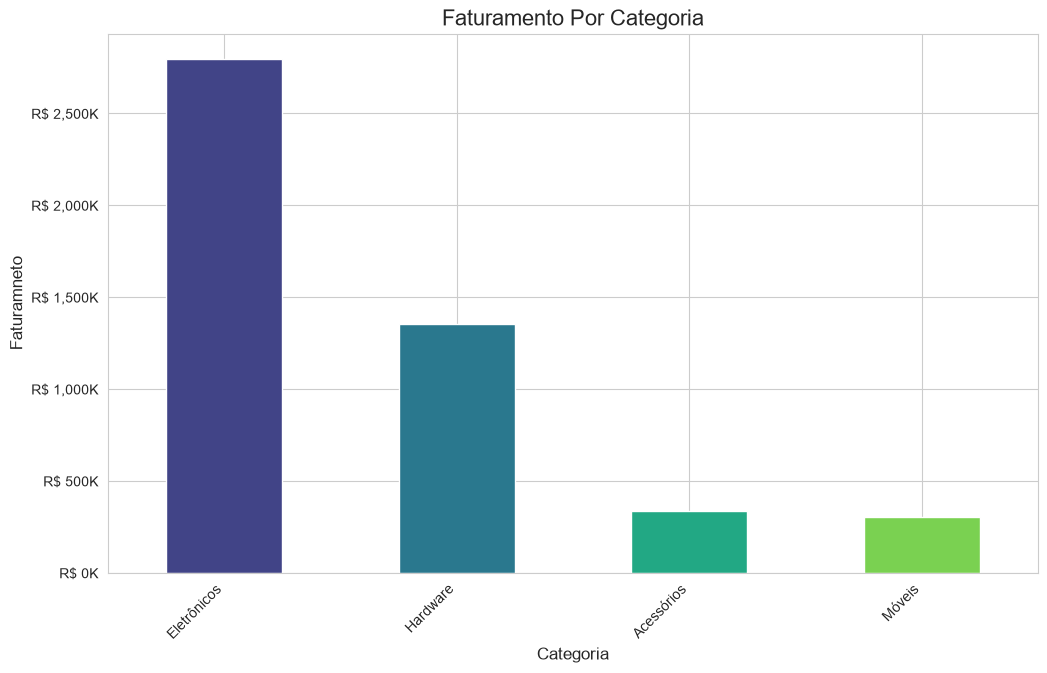

In [65]:
# O .map('{:,.2f}'.format) é opcional, mas deixa a visualização do número mais clara
from matplotlib.ticker import FuncFormatter
faturamneto_ordenado = faturamneto_categoria.sort_values(ascending = False)
fig, ax = plt.subplots(figsize= (12, 7))

def formatador_milhares(y, pos):
    """
    Formata o valor em milhares (K) com o cifrão R$.
    """
    return f'R$ {y/1000:,.0f}K'

formatter = FuncFormatter(formatador_milhares)

ax.yaxis.set_major_formatter(formatter)
faturamneto_ordenado.plot(kind = 'bar', ax = ax, color = sns.color_palette('viridis', len(faturamneto_ordenado)))
ax.set_title('Faturamento Por Categoria', fontsize = 16)
ax.set_xlabel('Categoria', fontsize = 12)
ax.set_ylabel('Faturamneto', fontsize = 12)
plt.xticks(rotation = 45, ha = 'right')
plt.thigt_layout()
plt.show()


## 10. Conclusão e Entrega do Resultado

Existem várias formas de entregar um projeto de análise de dados e a escolha depende do público, do contexto e dos objetivos. Três formas bastante utilizadas são:

**10.1. Relatório técnico ou executivo (PDF, DOCX, etc.)**

Essa forma é clássica e muito útil quando o público precisa de um documento formal para consulta. O relatório pode conter descrição da metodologia, exploração dos dados, gráficos, tabelas e conclusões. É comum separar a linguagem: uma versão mais técnica (com código, estatísticas detalhadas e testes) e outra mais executiva (com foco em insights, recomendações e storytelling de dados).

**10.2. Dashboard interativo (Power BI, Tableau, Looker, Streamlit, Dash, etc.)**

Um dashboard permite que os usuários explorem os dados por conta própria, filtrando informações, ajustando períodos de tempo ou focando em variáveis específicas. Essa forma de entrega é muito valorizada em ambientes corporativos, pois facilita a tomada de decisão contínua e não exige conhecimentos técnicos avançados dos usuários finais.

**10.3. Apresentação (slides em PowerPoint, Google Slides, etc.)**

Ideal para reuniões de stakeholders, a entrega em formato de apresentação resume os principais pontos do projeto. Ela foca nas descobertas mais relevantes, nas implicações para o negócio e nas recomendações práticas, usando gráficos e visualizações impactantes. A ideia é contar a história dos dados de forma clara e direta, evitando sobrecarregar o público com detalhes técnicos.

Confira exemplos práticos em <a href="https://www.datascienceacademy.com.br/course/storytelling-dashboards-e-tecnicas-de-apresentacao-para-cientistas-de-dados">Storytelling, Dashboards e Técnicas de Apresentação Para Cientistas de Dados</a>

Se isto aqui é um Mini-Projeto, então o que é um projeto inteiro na DSA? Nas Formações e Programas de Pós-Graduação você vai descobrir. ;-)

# Fim